## Astronomy 3350
### Data gathering demonstration and exercise
### Wednesday, November 5

Goals:
- Learn how to install packages that are not in the default SciServer configuration.
- Demonstrate data retrieval with an SQL query.
- Check that the returned data matched our query.

After that, I will define an exercise.  This will serve as the first assignment of the CURE research project on IC4665.

Authors:  Donald Terndrup and Dasha Crocker

Date of last revision: November 4, 2025

### We begin by importing packages.

We need `numpy`, `pandas`, `matplotlib`, and `astroquery`.

Of these, `astroquery` is not installed in SciServer by default.  The first
time you run this notebook, you need an external command called `pip` which
installs the package for you.  Subsequently, we can comment out the line that
installs `astroquery`.  If you do not comment out the line, you will get a
message that the request is already satisfied from a previous installation.

We begin by installing the packages that are usually available.

In [1]:
# Import plotting
import matplotlib.pyplot as plt

# Numerical python
import numpy as np

# Pandas
import pandas as pd

Now fetch `astroquery`.  We want only the part which handles the Gaia catalog.

In [2]:

# The exclamation mark in front of pip indicates command
# outside this python notebook.
! pip install astroquery    
from astroquery.gaia import Gaia

### Select a table we use to fetch data.

The `load_tables()` function returns a list of available tables.
There are a lot!  We want to show only those tables which refer
to the third data release of Gaia.  These tables have __dr3__
in their names. We also want to skip the early data release 3,
the tables for wich have __edr3__ in their names.

In [3]:
# Fetch the names of all the tables.
tables = Gaia.load_tables(only_names=True)
print('Number of tables fetched: %d \n' % len(tables))

# Show those tables that have `dr3` in their name. 
print('Gaia dr3 tables:')
for table in tables:
    name = table.name
    if 'dr3' in name and 'edr3' not in name:
        print('  ', name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
Number of tables fetched: 248 

Gaia dr3 tables:
   gaiadr3.gaia_source
   gaiadr3.gaia_source_lite
   gaiadr3.astrophysical_parameters
   gaiadr3.astrophysical_parameters_supp
   gaiadr3.oa_neuron_information
   gaiadr3.oa_neuron_xp_spectra
   gaiadr3.total_galactic_extinction_map
   gaiadr3.total_galactic_extinction_map_opt
   gaiadr3.commanded_scan_law
   gaiadr3.allwise_best_neighbour
   gaiadr3.allwise_neighbourhood
   gaiadr3.apassdr9_best_neighbour
   gaiadr3.apassdr9_join
   gaiadr3.apassdr9_neighbourhood
   gaiadr3.dr2_neighbourhood
   gaiadr3.gsc23_best_neighbour
   gaiadr3.gsc23_join
   gaiadr3.gsc23_neighbourhood
   gaiadr3.hipparcos2_best_neighbour
   gaiadr3.hipparcos2_neighbourhood
   gaiadr3.panstarrs1_best_neighbour
   gaiadr3.panstarrs1_join
   gaiadr3.panstarrs1_neighbourhood
   gaiadr3.ravedr5_best_neighbour
   gaiadr3.ra

The catalog we want is called `gaiadr3.gaia_source`.  We grab this catalog and display the
names of the columns.  We also show what type of an object we fetched. This is a object that holds properties of the catalog, and is not the whole catalog itself!
That would be far too large for us to consider right now.

In [4]:
# Get information on the table want for later
# data queries.
dr3 = Gaia.load_table('gaiadr3.gaia_source')
print(type(dr3), '\n')     # \n is 'newline' or a line break

print("Available data:")
for col in dr3.columns:
    print('  ', col.name)


<class 'astroquery.utils.tap.model.taptable.TapTableMeta'> 

Available data:
   solution_id
   designation
   source_id
   random_index
   ref_epoch
   ra
   ra_error
   dec
   dec_error
   parallax
   parallax_error
   parallax_over_error
   pm
   pmra
   pmra_error
   pmdec
   pmdec_error
   ra_dec_corr
   ra_parallax_corr
   ra_pmra_corr
   ra_pmdec_corr
   dec_parallax_corr
   dec_pmra_corr
   dec_pmdec_corr
   parallax_pmra_corr
   parallax_pmdec_corr
   pmra_pmdec_corr
   astrometric_n_obs_al
   astrometric_n_obs_ac
   astrometric_n_good_obs_al
   astrometric_n_bad_obs_al
   astrometric_gof_al
   astrometric_chi2_al
   astrometric_excess_noise
   astrometric_excess_noise_sig
   astrometric_params_solved
   astrometric_primary_flag
   nu_eff_used_in_astrometry
   pseudocolour
   pseudocolour_error
   ra_pseudocolour_corr
   dec_pseudocolour_corr
   parallax_pseudocolour_corr
   pmra_pseudocolour_corr
   pmdec_pseudocolour_corr
   astrometric_matched_transits
   visibility_periods_

### Start with a small query.

We define a docstring containing the parameters of
our query and send that query to be evaluated.  To begin, 
we will ask for a small number of stars and for a small
number of returned fields.  This will verify that we
know what type of data object is returned.

We will look at data in a small patch of the sky around
the [location of IC4665 from Simbad](https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=IC4665&submit=SIMBAD+search).  We'll also select a narrow range of
parallax around the cluster center.

Simbad lists the right ascension and declination in sexagesimal coordinates.
Let's write a function which returns the decimal values, which is what Gaia
contains.  We will save the center coordinates for later use.

In [5]:
# Function to return decimal coordinates from sexagesimal notation.
# This only works for positive values of declination.
def to_decimal(h, m, s, is_ra=False):
    """
    Converts hours/minutes/seconds or degrees/minutes/seconds
    to decimal degrees. Set is_ra = True for right ascensions
    so 0 to 24 hours maps onto 0 - 360 degrees.
    """
    value = h + m/60. + s/3600.
    if is_ra:
        value *= 15.
    return value

In [6]:
# IC 4665 coordinates
racen  = to_decimal(17, 46,  4.0, is_ra=True)
deccen = to_decimal( 5, 36, 54.0)
print('Right ascension: %6.1f' % racen)
print('Declination    : %6.1f' % deccen)

Right ascension:  266.5
Declination    :    5.6


In [33]:
# Pick stars within about 0.5 degree of the Simbad position
# and which are in a narrow range of parallax. The TOP number
# is the maximum number of data rows to return.
query = """SELECT TOP 10000
source_id, ra, dec, parallax
FROM gaiadr3.gaia_source
where parallax >= 2.75 and parallax <= 3.05 and ra >= 266.0
and ra <= 267 and dec >= 5.1 and dec <= 6.1
"""
# Launch the job and fetch the results.  You might have to
# wait a little for the results.  We'll make a pandas data
# frame out of the results.
job = Gaia.launch_job(query)
results = job.get_results().to_pandas()

Explore these data to see what was returned.

In [8]:
# Show data type.
print(type(results))

# Show length of the table.
print('Number of returned entries is %d \n' %len(results))

# List the columns
print('Columns:')
print(results.columns)

<class 'pandas.core.frame.DataFrame'>
Number of returned entries is 326 

Columns:
Index(['source_id', 'ra', 'dec', 'parallax'], dtype='object')


In [9]:
# Show the head of the pandas frame.
results.head()

,source_id,ra,dec,parallax
0,4474067191725116032,266.227598,5.665007,2.915236
1,4474067264743227392,266.211614,5.669701,3.007402
2,4474067294809802112,266.267308,5.654104,3.046893
3,4474069360686829824,266.308877,5.722443,2.754181
4,4474069596912741248,266.358947,5.741742,2.790539


In [10]:
# Show the tail of the pandas frame.
results.tail()

,source_id,ra,dec,parallax
321,4474065031359742080,266.384138,5.660569,3.010526
322,4474065061421346688,266.388982,5.668111,2.940302
323,4474065718554528512,266.331699,5.660861,2.929253
324,4474066401451091840,266.403858,5.711750,2.872700
325,4474066504530306688,266.390220,5.715654,2.938315


### Try a bigger query.

We will ask for a bigger selection on the sky and ask for more
returned fields.  This will overwrite the results from the previous
query.

We want to see if our data selection shows us the clustering
in proper motion space which we found in our recent laboratory.


In [38]:
query2 = """SELECT TOP 100000
source_id, ra, dec, parallax, pmra, pmdec
FROM gaiadr3.gaia_source
where parallax >= 2.75 and parallax <= 3.05 and ra >= 264.5
and ra <= 268.5 and dec >= 3.6 and dec <= 7.6
"""
job = Gaia.launch_job(query2)
results = job.get_results().to_pandas()

# Show length of the table.
print('Number of returned entries is %d \n' %len(results))

# List the columns
print('Columns:')
print(results.columns)

Number of returned entries is 3225 

Columns:
Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec'], dtype='object')


In [39]:
# Show the query with newlines replaced by spaces.
# This makes it easier to read.
query2.replace("\n", " ")

'SELECT TOP 100000 source_id, ra, dec, parallax, pmra, pmdec FROM gaiadr3.gaia_source where parallax >= 2.75 and parallax <= 3.05 and ra >= 264.5 and ra <= 268.5 and dec >= 3.6 and dec <= 7.6 '

In [13]:
results.head()

,source_id,ra,dec,parallax,pmra,pmdec
0,4486310940900232704,266.228946,6.818410,2.917896,-1.328439,-10.247269
1,4486311009619701248,266.227380,6.831811,3.021686,2.001751,0.598442
2,4486311078339330944,266.259224,6.837877,2.795349,-12.068426,-7.379222
3,4486311632385842816,266.296191,6.886969,2.788363,-3.309389,-3.300000
4,4486312143489650432,266.198120,6.874596,2.906866,-2.085902,-26.651202


### Display the resulting positions on the sky and proper motions.

Pick proper motions near the catalog mean value for the cluster.

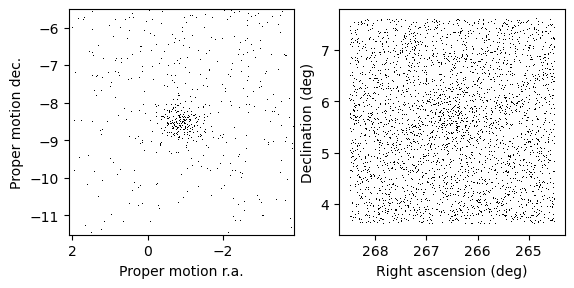

In [14]:
# Simbad proper motion center
muracen, mudeccen = -0.8993, -8.5114

# Half width of plot in proper motion
deltamu = 3

# Scribe the plot
fig, axes = plt.subplots(1,2)
axes[0].plot(results['pmra'], results['pmdec'], ',k')
axes[0].set_aspect('equal')
axes[0].set_xlim(muracen + deltamu, muracen - deltamu)
axes[0].set_ylim(mudeccen - deltamu, mudeccen + deltamu)
axes[0].set_xlabel('Proper motion r.a.')
axes[0].set_ylabel('Proper motion dec.')

# Second panel is celestial coordinates.
axes[1].plot(results['ra'], results['dec'], ',k')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Right ascension (deg)')
axes[1].set_ylabel('Declination (deg)')
axes[1].invert_xaxis()

### Show how to write a pandas frame as a csv file.

In [15]:
# Save the results file for later use.  We normally set a
# Boolean to be False so we don't save the file if we run
# the notebook several times.
savefile = False       # Set True to save file
if savefile:
    outfile = 'myIC4665.csv'
    print('Saving pandas frame to file %s' % outfile)
    results.to_csv(outfile)

---
### An exercise

Create a new query below to select:
- stars with G magnitude <= 19.5
- stars between half and twice the distance to the cluster from Simbad
- stars with r.a. within 5 degrees of the cluster center
- stars with declination within 5 degrees of the cluster center

You want to gather more columns than in our example.  In addition to the
ones above, fetch
- the error in the parallax
- errors in proper motion in r.a. and in declination
- the mean G magnitude (_not_ the flux)
- the mean Bp magnitude and the mean Rp magnitude
- the radial velocity and its error
- the flag identifying a star as a photometric variable
- the __ruwe__ number, which can indicate multiplicity (binaries, triples, etc.)

Check that the number of returned items is not equal to the value you
set with __TOP__.  If it is, increase the value of TOP.

Then do a few computations and plots as a first inspection of the data set:
- Show the head and tail of the file, and print the number of entries.
- Demonstrate that a narrow distance slice of the resulting pandas frame shows a proper motion clustering in the expected place.
- Plot errors in the G, Bp, and Rp magnitudes as a function of G magnitude.
- Compute the distance to the nearest and the most distant star in the collection.

Save the file on SciServer for later use.  Upload your notebook, but not the data file,
to Carmen.


In [94]:
racen  = 266.5  
deccen =   5.6

p0    = 2.9
pmin  = p0 / 2.0
pmax  = p0 * 2.0

ra_min  = racen  - 5.0
ra_max  = racen  + 5.0
dec_min = deccen - 5.0
dec_max = deccen + 5.0

TOPN = 300000    

In [82]:
query3 = """SELECT TOP 100000
source_id, ra, dec, parallax, parallax_error, pmra, pmra_error, pmdec, pmdec_error
FROM gaiadr3.gaia_source
where parallax >= 1.45 and parallax <= 5.8 and ra >= 261.5 and ra <= 271.5 and dec >= 0.6 and dec <= 10.6
"""


In [109]:

job3 = Gaia.launch_job(query3)
results = job3.get_results().to_pandas()

print("Rows returned:", len(results))

Rows returned: 100000


In [84]:
print("\nHEAD:")
display(results.head())



HEAD:


,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error
0,4390528978307045120,261.500022,5.388687,1.534784,0.451388,-6.337090,0.374817,-5.566945,0.311765
1,4390888930927986176,261.500046,6.245533,1.683475,0.210251,0.094754,0.206511,-32.929445,0.175754
2,4491860077299708672,261.500056,10.220448,2.212330,0.460128,5.803566,0.395957,-4.098748,0.361674
3,4389201631550993408,261.500129,3.910374,1.792221,1.961614,12.791687,1.439085,-0.470261,1.475596
4,4390900514456107648,261.500142,6.419071,2.911790,0.055922,-21.786362,0.053492,-25.423278,0.043869


In [85]:
print("\nTAIL:")
display(results.tail())


TAIL:


,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error
99995,4489330272840187776,264.902211,9.614736,4.001211,2.617481,-2.683230,2.513994,-4.620531,2.849074
99996,4487740683970044032,264.902222,8.892236,2.558486,0.153138,3.731097,0.147487,-13.135075,0.128129
99997,4376979872611187840,264.902245,2.848960,3.068401,1.311734,-1.259847,1.634071,-4.494702,0.914390
99998,4485807295855021696,264.902262,5.969603,3.139514,0.709906,-4.114044,0.776743,-33.919462,0.588526
99999,4489262408063338624,264.902290,9.194157,2.082708,0.318400,-0.185666,0.274830,5.942101,0.259760


In [115]:
query4 = """
SELECT TOP 100000
    source_id,
    ra, dec,
    parallax,
    pmra, pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe
FROM gaiadr3.gaia_source
WHERE
    phot_g_mean_mag <= 19.5
    AND parallax >= 1.45
    AND parallax <= 5.8
    AND ra  >= 263.5
    AND ra  <= 269.5
    AND dec >= 2.6
    AND dec <= 8.6
"""


In [116]:
job4 = Gaia.launch_job(query4)
results = job4.get_results().to_pandas()

print("Rows returned:", len(results))

Rows returned: 41081


In [121]:
print("Number of stars:", len(results))
display(results.head())


Number of stars: 41081


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe
0,4469550329238980608,269.450686,3.177875,3.467648,-1.985360,3.971496,18.612822,18.854572,17.749811,2.912024
1,4469551085153252736,269.440448,3.187740,1.608915,-7.185698,1.450342,18.843697,20.218145,17.659492,1.055515
2,4469551119512998912,269.421544,3.189984,2.489356,3.153167,4.821292,16.874523,18.077103,15.796886,1.039704
3,4469551501771122560,269.440407,3.236599,2.838559,-31.226724,-2.860372,17.601994,18.727577,16.567602,0.995543
4,4469551673569807360,269.461889,3.228540,1.574335,2.596648,-15.303604,15.649941,16.316217,14.869110,0.961543


In [122]:
display(results.tail())

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe
41076,4486288233408353024,265.736166,7.110018,1.488323,5.103642,-3.378726,14.679381,15.126618,14.062126,0.986387
41077,4486288370847299072,265.784479,7.111226,3.725487,1.104103,-3.664108,12.324467,12.719699,11.760004,0.954293
41078,4486288710147998208,265.748774,7.138474,1.950795,-5.342705,-28.563526,19.154486,20.601826,18.031008,0.978295
41079,4486288744507740800,265.769307,7.153108,1.479405,-0.925866,-15.741695,18.814011,20.278305,17.646954,1.026684
41080,4486288783164289664,265.783008,7.145664,1.734594,-2.327878,0.330100,14.033250,14.473279,13.425844,0.948597


Stars in slice: 2441


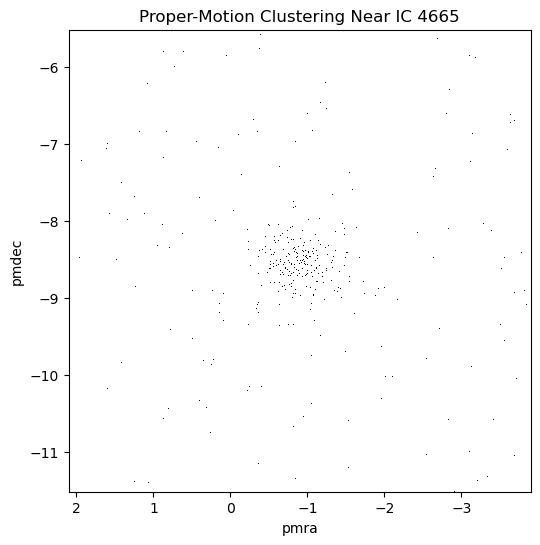

In [128]:
p0 = 2.9
dp = 0.15

mask = (results["parallax"] >= p0 - dp) & (results["parallax"] <= p0 + dp)
narrow = results[mask]

print("Stars in slice:", len(narrow))

muracen, mudeccen = -0.8993, -8.5114

plt.figure(figsize=(6,6))
plt.plot(narrow["pmra"], narrow["pmdec"], ",k")
plt.gca().set_aspect("equal")

dmu = 3
plt.xlim(muracen + dmu, muracen - dmu)
plt.ylim(mudeccen - dmu, mudeccen + dmu)

plt.xlabel("pmra")
plt.ylabel("pmdec")
plt.title("Proper-Motion Clustering Near IC 4665")
plt.show()

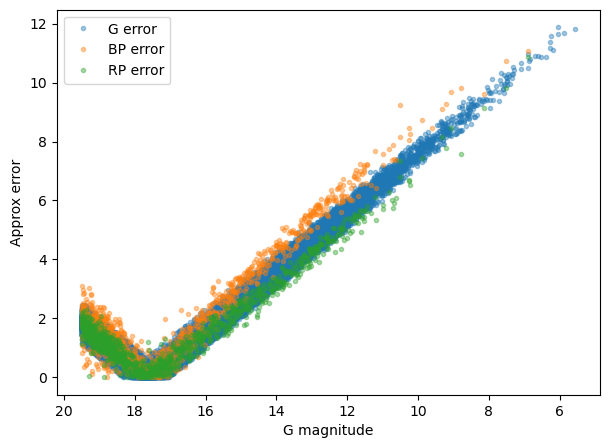

In [127]:
G = results["phot_g_mean_mag"]

G_med  = G.rolling(window=200, center=True).median()
Bp_med = results["phot_bp_mean_mag"].rolling(window=200, center=True).median()
Rp_med = results["phot_rp_mean_mag"].rolling(window=200, center=True).median()

dG  = abs(G - G_med)
dBp = abs(results["phot_bp_mean_mag"] - Bp_med)
dRp = abs(results["phot_rp_mean_mag"] - Rp_med)

plt.figure(figsize=(7,5))
plt.plot(G, dG, ".", alpha=0.4, label="G error")
plt.plot(G, dBp, ".", alpha=0.4, label="BP error")
plt.plot(G, dRp, ".", alpha=0.4, label="RP error")
plt.gca().invert_xaxis()
plt.xlabel("G magnitude")
plt.ylabel("Approx error")
plt.legend()


In [125]:
mask_pos = results["parallax"] > 0
dist_pc = 1000 / results.loc[mask_pos, "parallax"]

print("Nearest star:", dist_pc.min(), "pc")
print("Farthest star:", dist_pc.max(), "pc")

Nearest star: 172.4410903326213 pc
Farthest star: 689.6454158099762 pc
